Завантаження та попередня обробка даних

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')
%matplotlib inline

In [7]:
data_path = 'train1.csv'
if os.path.exists(data_path):
    df = pd.read_csv(data_path)
else:
    raise FileNotFoundError(f"Файл {data_path} не знайдено.")

Загальна інформація про дані

In [8]:
df.head()
df.info()
df.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


Перевірка пропущених значень

In [9]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Заповнення пропусків і кодування категоріальних ознак

In [10]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Fare'] = df['Fare'].fillna(df['Fare'].median())
df = df.drop(['Cabin', 'Name', 'Ticket'], axis=1)
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1}).astype(int)
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2}).astype(int)

In [11]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
dtype: int64

Підсумковий набір ознак

In [12]:
df.head()
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Sex              int64
Age            float64
SibSp            int64
Parch            int64
Fare           float64
Embarked         int64
dtype: object

Розбиття на навчальну та тестову вибірки

In [13]:
from sklearn.model_selection import train_test_split
X = df.drop('Survived', axis=1)
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('X_train shape:', X_train.shape, 'y_train shape:', y_train.shape)
print('X_test shape:', X_test.shape, 'y_test shape:', y_test.shape)
print('Train class distribution:')
print(y_train.value_counts(normalize=True))
print('Test class distribution:')
print(y_test.value_counts(normalize=True))

X_train shape: (712, 8) y_train shape: (712,)
X_test shape: (179, 8) y_test shape: (179,)
Train class distribution:
Survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64
Test class distribution:
Survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


Навчання дерева рішень

In [14]:
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(random_state=52)
if 'PassengerId' in X_train.columns:
    X_train = X_train.drop('PassengerId', axis=1)
    X_test = X_test.drop('PassengerId', axis=1)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print('Depth:', clf.get_depth())
print('Number of nodes:', clf.tree_.node_count)
pd.DataFrame({'y_true': y_test.reset_index(drop=True), 'y_pred': pd.Series(y_pred)}).head()

Depth: 23
Number of nodes: 309


,y_true,y_pred
0,0,0
1,0,0
2,1,0
3,0,0
4,1,1


Оцінювання якості класифікації

Accuracy: 0.8212
Precision: 0.7846
Recall: 0.7391
F1-score: 0.7612

Classification report:
              precision    recall  f1-score   support

           0     0.8421    0.8727    0.8571       110
           1     0.7846    0.7391    0.7612        69

    accuracy                         0.8212       179
   macro avg     0.8134    0.8059    0.8092       179
weighted avg     0.8199    0.8212    0.8202       179



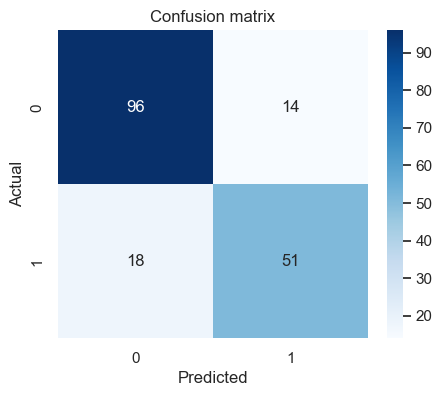

In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f'Accuracy: {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall: {rec:.4f}')
print(f'F1-score: {f1:.4f}')
print('\nClassification report:')
print(classification_report(y_test, y_pred, digits=4))
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion matrix')
plt.show()

Для інтерпретації побудованого дерева рішень проаналізуємо важливість ознак. Важливість ознаки показує, наскільки сильно ця ознака використовувалась деревом під час поділу даних на класи.

Важливість ознак:
     Ознака  Важливість
0       Sex    0.316638
1       Age    0.254105
2      Fare    0.234952
3    Pclass    0.110281
4  Embarked    0.038262
5     Parch    0.026327
6     SibSp    0.019436


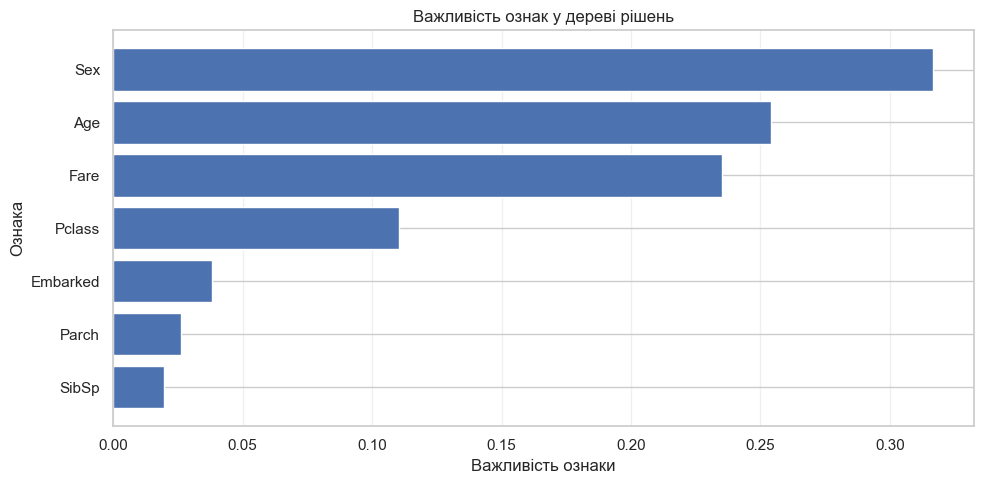

In [16]:
feature_importance = pd.DataFrame({
    'Ознака': X_train.columns,
    'Важливість': clf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Важливість',
    ascending=False
).reset_index(drop=True)

print("Важливість ознак:")
print(feature_importance)

plt.figure(figsize=(10, 5))
plt.barh(feature_importance['Ознака'], feature_importance['Важливість'])
plt.gca().invert_yaxis()
plt.xlabel('Важливість ознаки')
plt.ylabel('Ознака')
plt.title('Важливість ознак у дереві рішень')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
top_features = feature_importance.head(3)

print("Найбільш важливі ознаки:")
for i, row in top_features.iterrows():
    print(f"{i + 1}. {row['Ознака']} — {row['Важливість']:.4f}")

Найбільш важливі ознаки:
1. Sex — 0.3166
2. Age — 0.2541
3. Fare — 0.2350


Для кращого розуміння роботи моделі візуалізуємо дерево рішень. Оскільки повне дерево має велику глибину, для зручності відображаємо лише перші рівні дерева.

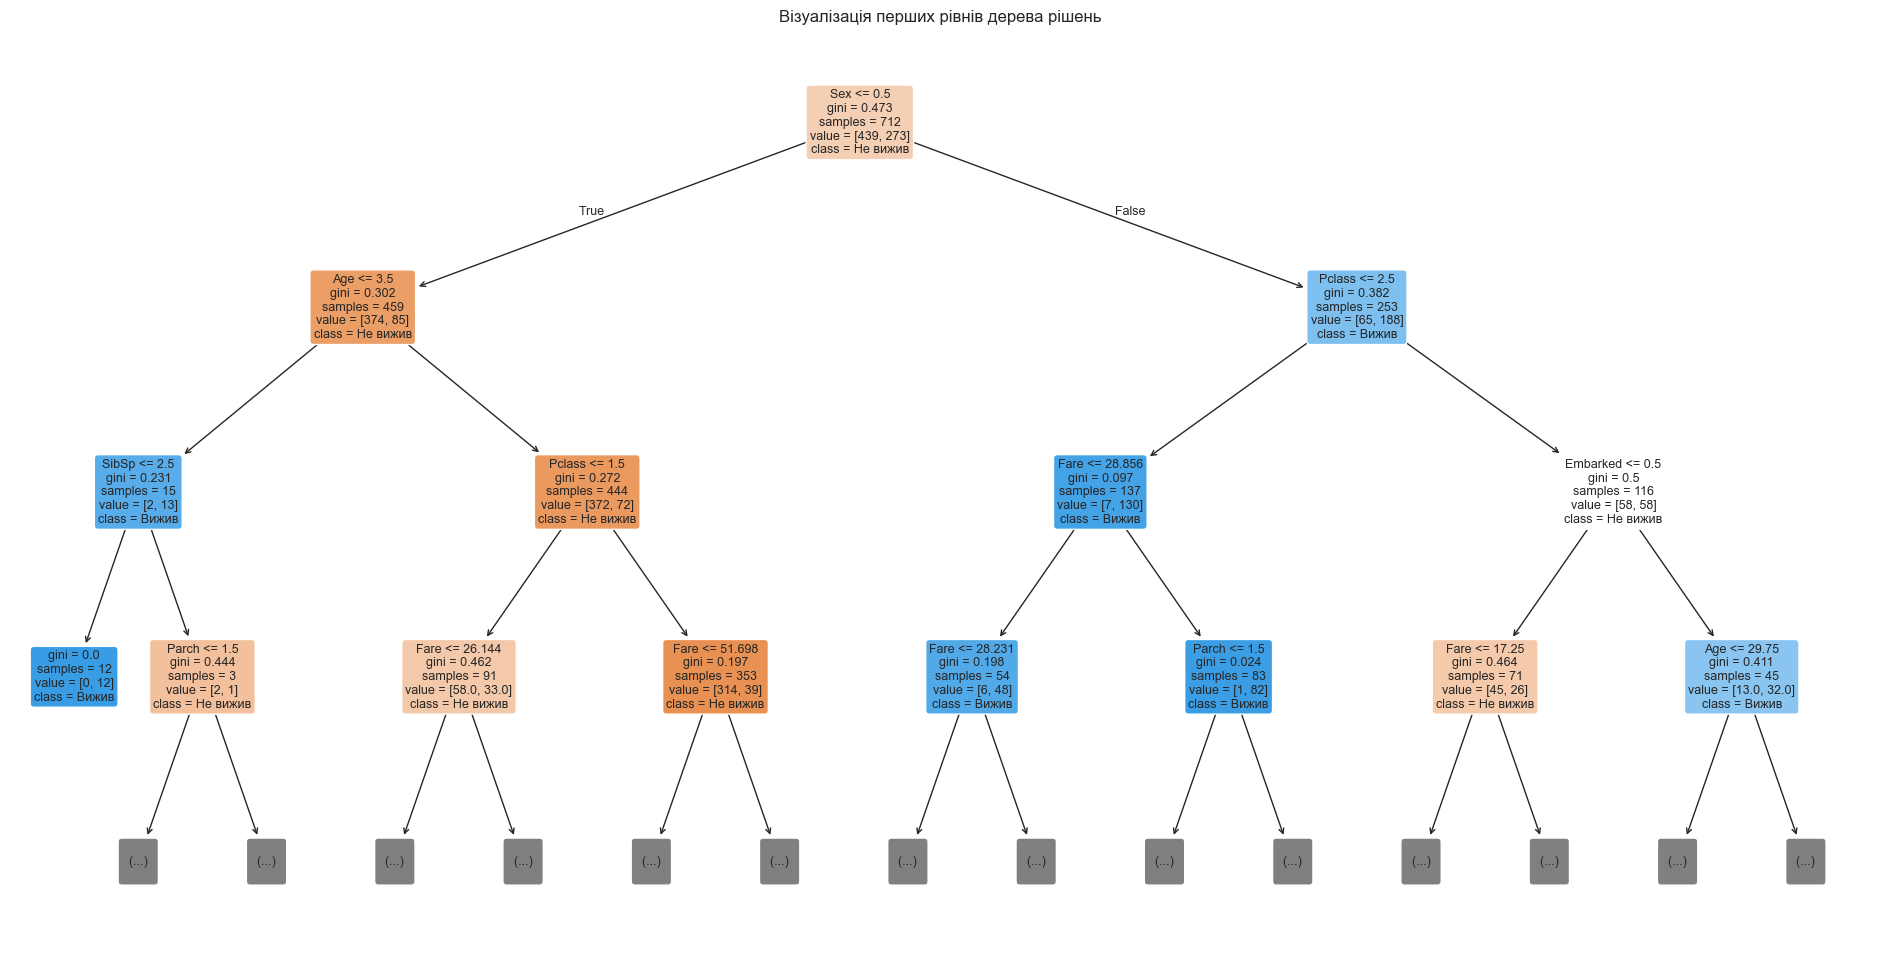

In [19]:
from sklearn.tree import plot_tree

plt.figure(figsize=(24, 12))

plot_tree(
    clf,
    feature_names=X_train.columns,
    class_names=['Не вижив', 'Вижив'],
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=3
)

plt.title('Візуалізація перших рівнів дерева рішень')
plt.show()

На візуалізації показано перші рівні дерева рішень. Кожен вузол містить умову поділу, наприклад перевірку певної ознаки та її порогового значення. Якщо умова виконується, об’єкт переходить в одну гілку дерева, якщо ні — в іншу. Дерево рішень поступово розділяє пасажирів на групи так, щоб у кожній групі було якомога більше об’єктів одного класу. У тобто листках дерева, модель приймає рішення про клас пасажира: вижив або не вижив.

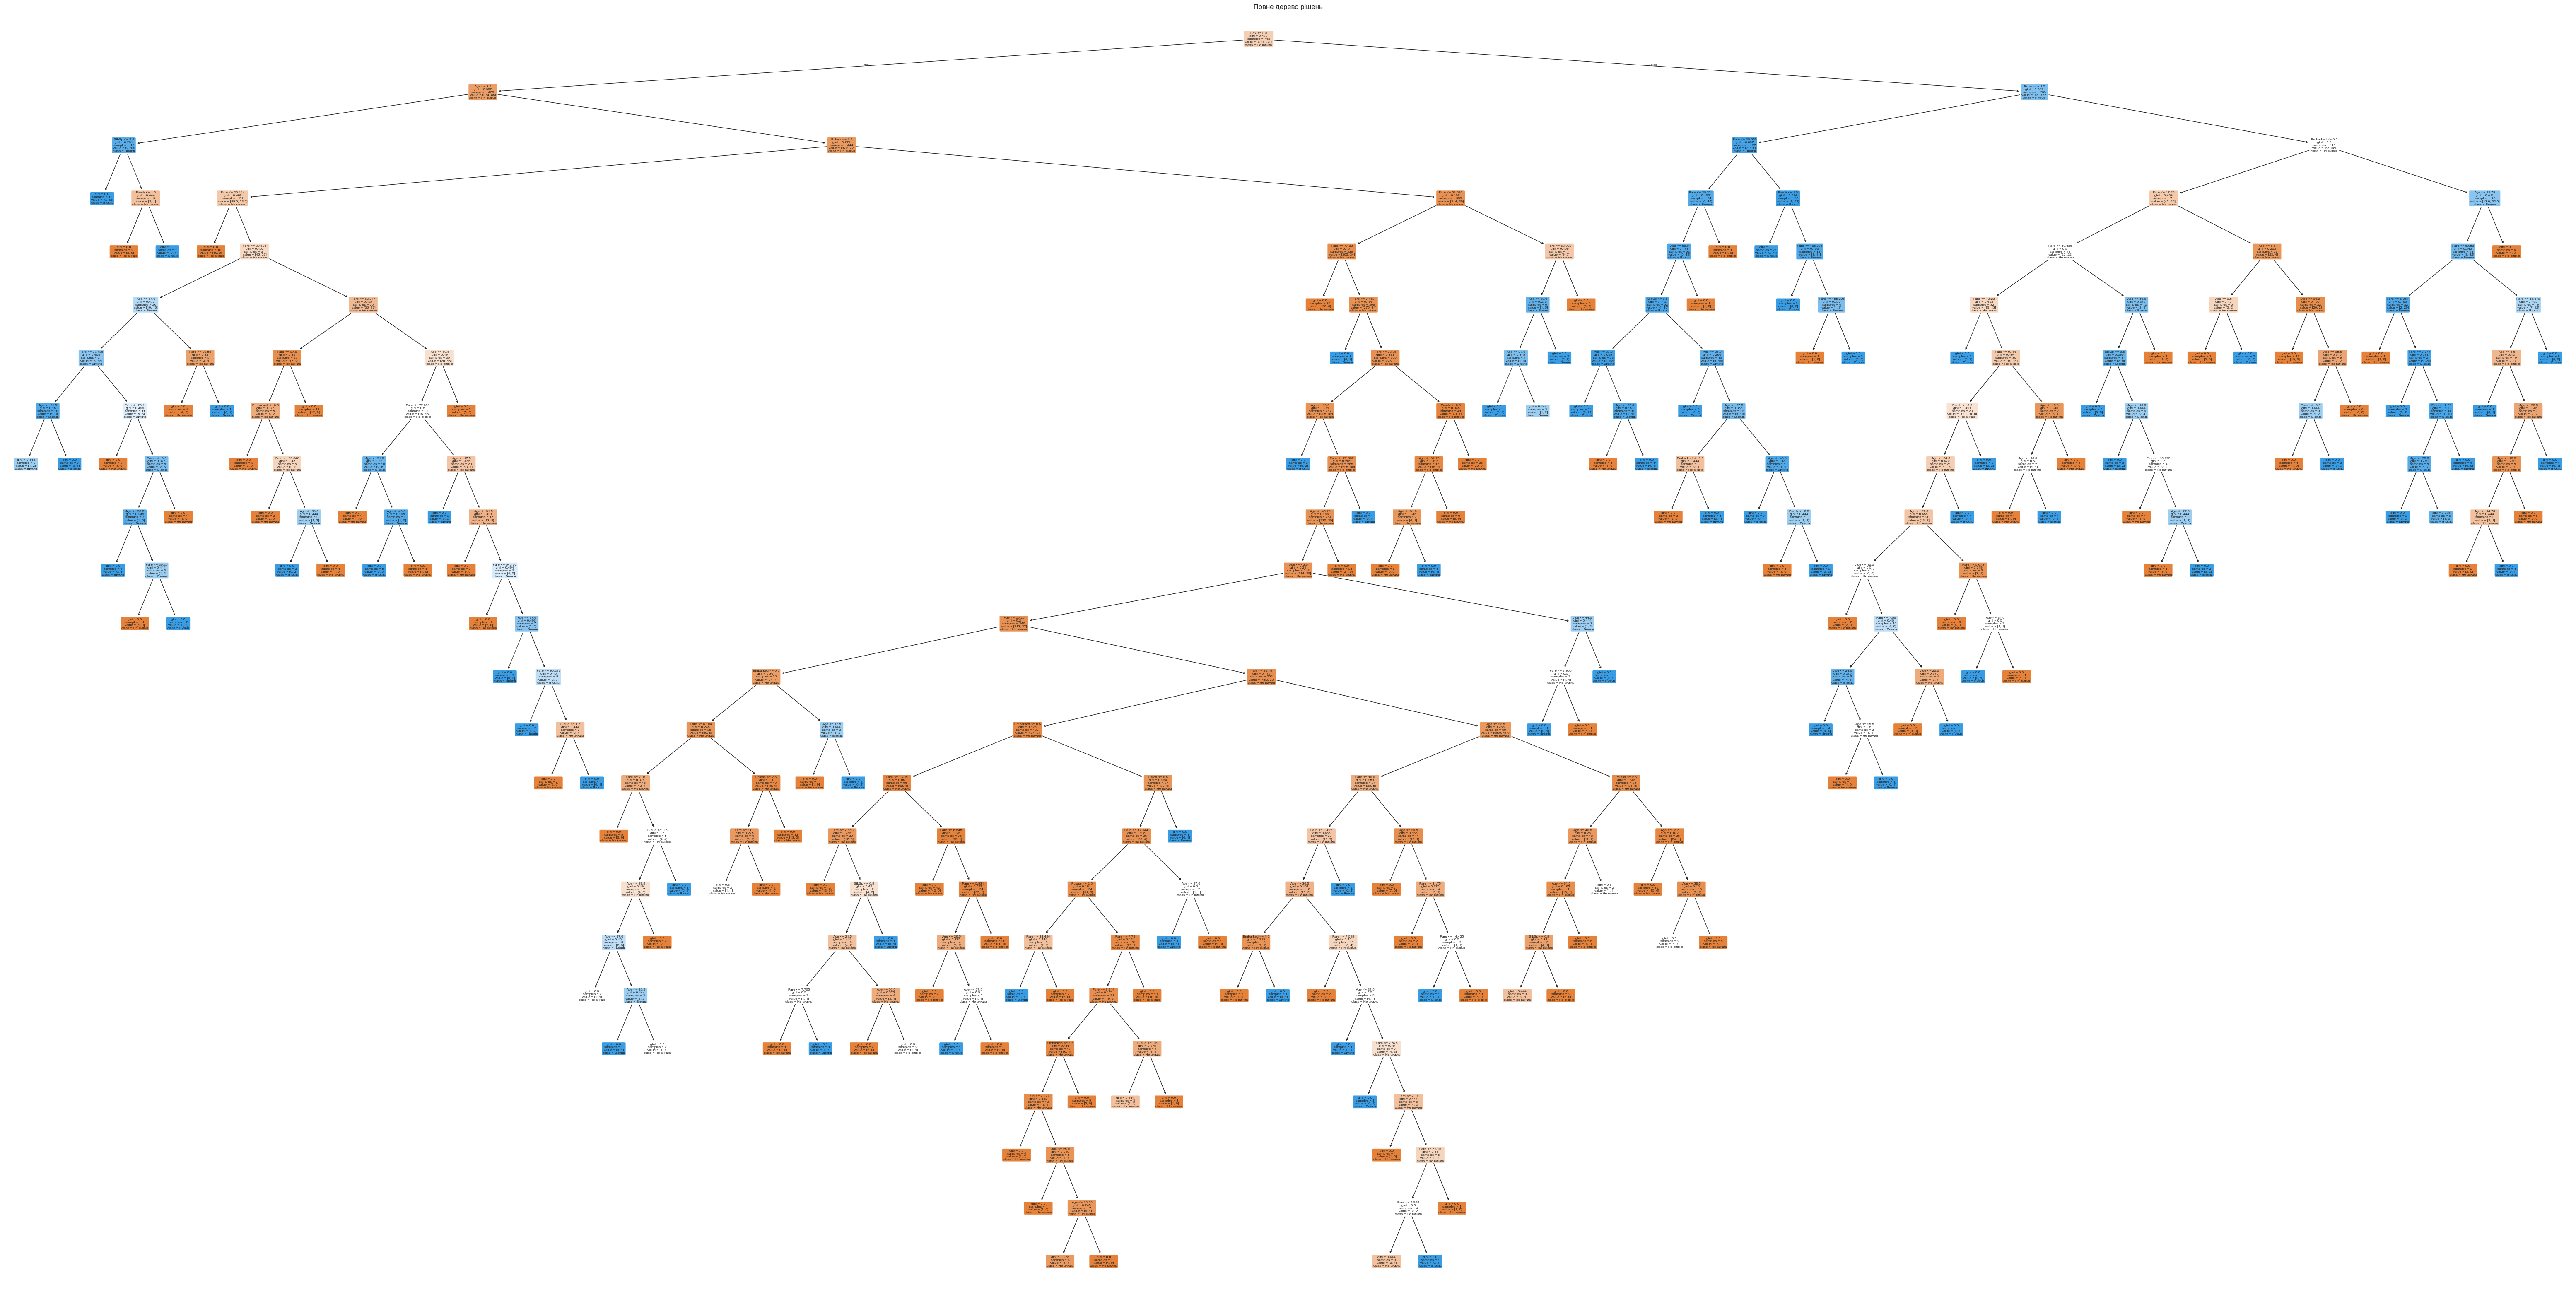

In [20]:
plt.figure(figsize=(80, 40))

plot_tree(
    clf,
    feature_names=X_train.columns,
    class_names=['Не вижив', 'Вижив'],
    filled=True,
    rounded=True,
    fontsize=6
)

plt.title('Повне дерево рішень')
plt.show()